In [1]:
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as integrate
import matplotlib.ticker as ticker

%load_ext autoreload
%autoreload 2

from GP_code import simulate_population_single, get_mean_trajectory_single, simulate_population_double 
from GP_code import get_mean_trajectory_double, simulate_pulsed_therapy, mean_pulsed_therapy
from GP_code import get_concentration



In [2]:
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate
    mu = 0.08 # Death rate increases over time
    return l, mu

In [3]:
#True value: E[Z(t)]
import scipy.integrate as integrate

def func(t):
    return (0.05 * np.sin(0.1 * t) + 0.1) - 0.08

def func_sens(t):
    return np.exp(0.05/0.1 + (0.1-0.08)*t - (0.05/0.1)*np.cos(0.1*t)) * (0.05*np.sin(0.1 * t) + 0.1)


def calc_expectation(Z0, func, t):
    value, error = Z0 * np.exp(integrate.quad(func, 0, t))
    return value

def calc_cell_division(func_sens, t):
    '''
    Top right of page 183
    '''
    
    value, error = integrate.quad(func_sens, 0, t)
    return value



In [4]:
vals = np.linspace(0, 250, 250)
store = np.zeros(len(vals))
for i, _ in enumerate(vals):
    store[i] = calc_expectation(1, func, _)
    

Fig 1(a): E[Y(t)]: Expected number of sensitive cells for a single-type non-homogenous birth-death process

This is the analytical approximation $$E[Z(t)] = Z_0exp[\int_0^t (\lambda (\tau ) - \mu (\tau )) d \tau ]$$
lambda and mu are given in the function example_rates_single as above

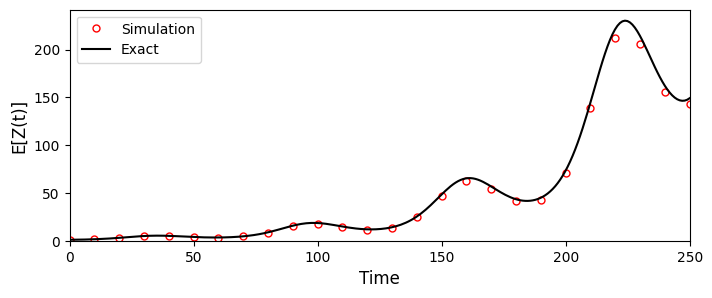

In [ ]:
#Need 10000+ trials to get an accurate figure. Can take oer 10 minutes
#N = 10000 #Number of trials
fig = plt.figure(figsize=(8, 3))
grid, mean_pop, mean_divs, var = get_mean_trajectory_single(N, 250, 1, example_rates_single, 0.3)
plt.plot(grid, mean_pop, 'o', markevery = 10, markersize = 5, 
         c = 'red', label = f'Simulation', fillstyle = 'none')
plt.plot(vals, store, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()
plt.xlim(0, 250)
plt.ylim(0, None)
plt.xlabel('Time', fontsize=12)
plt.ylabel('E[Z(t)]', fontsize=12)

#uncomment to overwrite figure
#plt.savefig('Figs/single_type_population.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 1 (b): birth-death rate over time

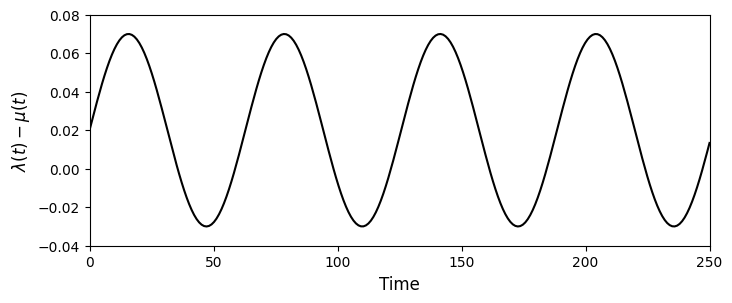

In [24]:
time = np.linspace(0, 250, 250)
y_axis = np.zeros(len(time))
for i, n in enumerate(time):
    y_axis[i] = func(n)
fig = plt.figure(figsize=(8, 3))
plt.plot(time, y_axis, c = 'black')
plt.xlim(0, 250)
plt.ylim(-0.04, 0.08)
plt.xlabel('Time', fontsize=12)
plt.ylabel(r'$\lambda(t) - \mu(t)$', fontsize=12)

#uncomment to overwrite figure
plt.savefig('Figs/single_type_net_growth_rate.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [26]:
vals_c = np.linspace(0, 250, 250)
store_c = np.zeros(len(vals_c))
for i, _ in enumerate(vals_c):
    store_c[i] = calc_cell_division(func_sens, _)

Fig 1(c): Number of sensitive cell divisions

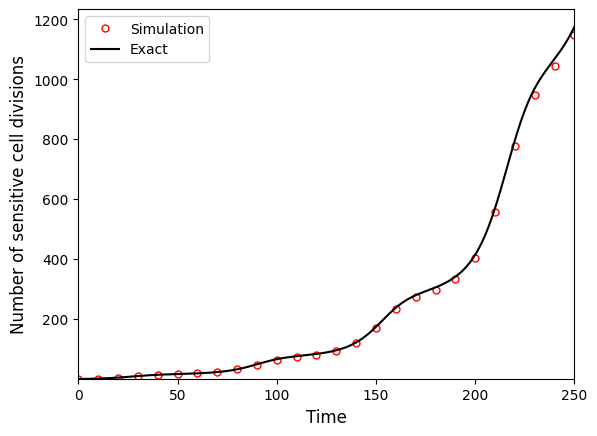

In [ ]:
plt.plot(grid, mean_divs,'o', markevery = 10, markersize = 5, fillstyle = 'none', 
         c = 'red', label = f'Simulation' )
plt.plot(vals_c, store_c, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()
plt.xlim(0, 250)
plt.ylim(1, None)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of sensitive cell divisions', fontsize=12)
#uncomment to overwrite figure
#plt.savefig('Figs/single_type_divisions.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 1(extra): Variance

In [4]:
#parameters as per Fig 1a
A = 0.05
theta = 0.1
B = 0.1
C = 0.08
M0 = 1

#function for numerical solution
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = A * np.sin(theta * t) + B # Birth rate
    mu = C # Death rate increases over time
    return l, mu

#--------------------------------------------------------

#Analytical solution
def lamb(t):
    return A * np.sin(theta * t) + B

def mu(t):
    return C

def w(tau):
    def integrand(neb):
        return  mu(neb) - lamb(neb)
    value, error = integrate.quad(integrand, 0, tau)
    return np.exp(value)

def var_single(t):
    def integrand(tau):
        return (lamb(tau) + mu(tau)) * w(tau)
    value, error = integrate.quad(integrand, 0, t)
    return M0 * w(t)**(-2) * value
        

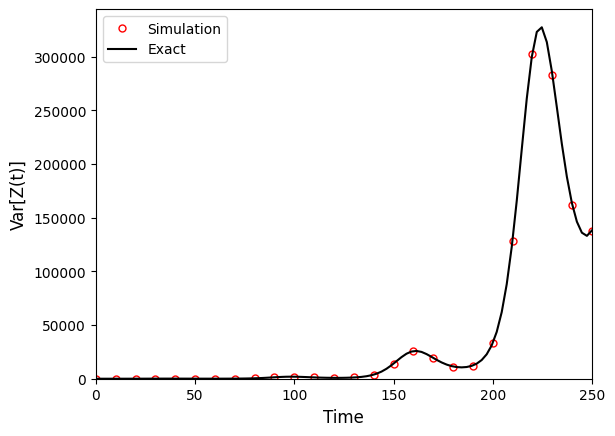

In [ ]:
#N = 5000 #Number of trials. Need a lot for this (~5000)
T = 250
beta = 0.7


grid, mean_pop, mean_r, var = get_mean_trajectory_single(N, T, M0, example_rates_single, beta)
plt.plot(grid, var, 'o', markevery = 10, markersize = 5, fillstyle = 'none', 
         c = 'red', label = f'Simulation' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_single(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()

plt.xlim(0, 250)
plt.ylim(0, None)

plt.xlabel('Time', fontsize=12)
plt.ylabel('Var[Z(t)]', fontsize=12)
#uncomment to overwrite figure
#plt.savefig('Figs/single_type_variance.pdf', format='pdf', bbox_inches='tight', dpi=300)


plt.show()

Fig 2(a): Expected number of resistant cells

In [5]:
def example_rates_double(t, B1, C2):
    # Example: rates depend on drug concentration
    l_x = 0.05 * np.sin(0.1 * t) + B1 # Birth rate sensitive cells
    l_y = 0.05 * np.sin(0.1 * t) + 0.12 # Birth rate resistant cells
    mu_x = 0.14 # death rate of sensitive cells
    mu_y = C2 # death rate of resistant cells
    return l_x, l_y, mu_x, mu_y

In [ ]:
#Define analytical result of expected size of resistant cell population
#l_x = 0.05sin(0.1t)+0.1
#mu_x = 0.14
#l_y = 0.05sin(0.1t)+0.12
#mu_y = [0.09, 0.1, 0.11]
#M = 100
#u = 10**-3

#Using R(t), bottom left page 181

def b_tau(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def R_t(t, C2):
    def integral(tau):
        #b_tau(t)
        term1 = (0.05/0.1)*np.cos(0.1*tau) - (0.05/0.1)*np.cos(0.1*t) + (0.12-C2)*t +(C2-0.12)*tau
        func = b_tau(tau)*np.exp(term1)
        return func
    value, error = integrate.quad(integral, 0, t)
    return value

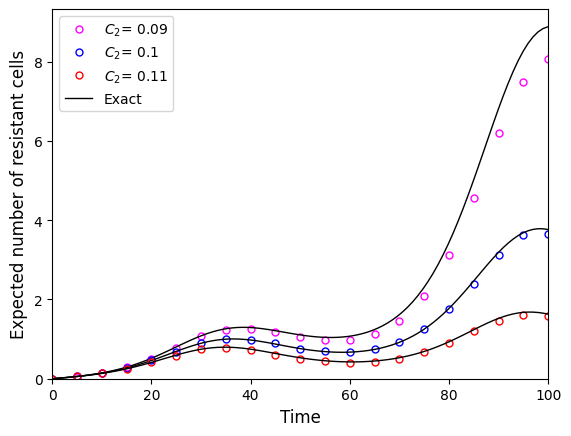

In [13]:
N = 5000 #Number of trials
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
B1 = 0.1
c_vals = [0.09, 0.1, 0.11]
colours = ['magenta','blue','red']
_ = zip(c_vals, colours)
count = 0

for C2, color in _:
    grid, mean_pop, mean_r, probs, var_r = get_mean_trajectory_double(N, T_max, M0, R0, example_rates_double, beta, u, B1, C2)
   
    # plt.plot(grid, mean_r, c = 'red', label = f'Numerical solution: {N} trials, C2 = {C2}' )
    plt.plot(grid, mean_r, 'o', c = color, markersize = 5, markevery = 5, fillstyle = 'none', label = r'$C_2$' f'= {C2}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))

    for i, _ in enumerate(vals_r):
        store_r[i] = R_t(_, C2)

    #Simple counter to only add 'Exact' to the legend once    
    if count == 2:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', linewidth=1, label = 'Exact')
    else:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', linewidth=1)
    count += 1
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, None)

plt.xlabel('Time', fontsize=12)
plt.ylabel('Expected number of resistant cells', fontsize=12)

#uncomment to overwrite figure
plt.savefig('Figs/double_type_population.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 2(b): Probability of Resistance

In [14]:
#b_tau already defined
#We are looking for P_r(T) = 1- exp(integral(-b + b * P_ext dt)from 0 T)
#define p_ext as Q/1+Q
def b_t(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def P_rt (t, T, B1):
    def P_exp():
        def integral(t, T):
            def Q(tau):
                #b_tau(t)
                term1 = (0.05/0.1)*np.cos(0.1*(tau+t)) - (0.05/0.1)*np.cos(0.1*t) - (0.1)*tau
                func = 0.1*np.exp(term1)
                return func
            value, error = integrate.quad(Q, 0, T-t)
            return value
        p_exp = integral/(1+integral)
        return p_exp
    term = -b_t(t) + (b_t(t) * P_exp)
    value, error = integrate.quad(term, 0, T)
    return 1 - np.exp(value)

In [15]:
M = 100
u = 1e-3
theta = 0.1
A = 0.05
C1 = 0.14
B2, C2 = 0.12, 0.1 

def get_b_t(t, B1):
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def get_Q(t, T):
    # Q is the integral from 0 to (T-t)
    def Q_integrand(tau):
        q_exp = (A/theta)*np.cos(theta*(t+tau)) - (A/theta)*np.cos(theta*t) - (B2 - C2)*tau
        return C2 * np.exp(q_exp)

    val, _ = integrate.quad(Q_integrand, 0, T - t)
    return val

def get_P_ext(t, T):
    Q_val = get_Q(t, T)
    return Q_val / (1 + Q_val)

def P_R(T, B1):
    # Final integral from 0 to T of [-b(t) + b(t)*P_ext(t,T)]
    def final_integrand(t):
        bt = get_b_t(t, B1)
        pext = get_P_ext(t, T)
        return -bt + (bt * pext)

    integral_val, _ = integrate.quad(final_integrand, 0, T)
    return 1 - np.exp(integral_val)

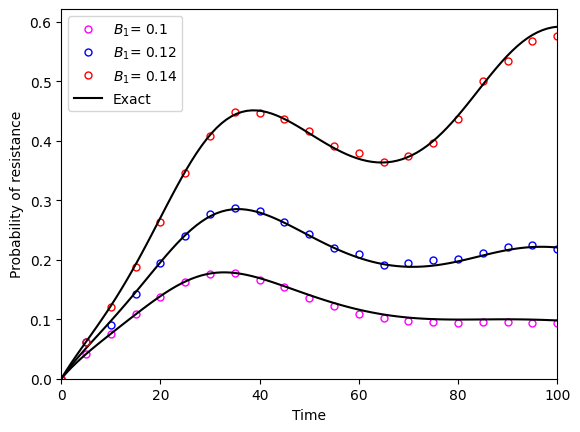

In [21]:
N = 2500 #Number of trials. Need a lot for this
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1

count = 0
B_ = [0.1, 0.12, 0.14]
colours = ['magenta','blue','red']
_ = zip(B_, colours)
for B1, cols in _ :
    grid, mean_pop, mean_r, probs, var = get_mean_trajectory_double(N, T_max, M0, R0, 
                                                               example_rates_double, beta, u, B1, C2)
    plt.plot(grid, probs, 'o', markersize = 5, markevery = 5, fillstyle = 'none', c = cols, label = r'$B_1$' f'= {B1}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = P_R(_, B1)
    if count == 2:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Exact')
    else:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-')
    count += 1
plt.legend()

plt.xlim(0, 100)
plt.ylim(0, None)

plt.ylabel('Probability of resistance')
plt.xlabel('Time')

plt.savefig('Figs/double_type_probability.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 2(c): Variance of resistant cell population

In [37]:
#Analytical solution
#need to define lamba_y, w_hat, and b.
#we can use b as per above
A = 0.05
theta = 0.1
B1 = 0.1
B2 = 0.12
C1 = 0.14
C2 = 0.1

M = 100
u = 1e-3


def get_b_t(t):
    # This is b(t): the rate of production of resistant cells at time t
    # Integral of (l_x - mu_x) = (A/y) - (A/y)cos(yt) + (B1-C1)t
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def lambda_y(z):
    #z = tau + t
    result = A * np.sin(theta * z) + B2
    return result

def w_hat(o, t):
    #o can be tau, T-t, etc.
    def integrand(n):
        return C2 - lambda_y((n+t))
    integ, _ = integrate.quad(integrand, 0, o)
    return np.exp(integ)

def integ_1(t, T):
    #integral within variance integral
    #integral of w(tau, t) * lambdaY(tau + t) dtau from 0 to T-t
    def integrand(tau):
        z = tau + t
        term = w_hat(tau, t) * lambda_y(z)
        return term
    value, _ = integrate.quad(integrand, 0, (T-t))
    return value

def var_R(T):
    #Variance of population of resistance cells
    def integrand(t):
        o = T-t
        w = w_hat(o, t)
        numerator = get_b_t(t) * (w + (2 * integ_1(t, T)))
        denominator = w**2
        full = numerator / denominator
        return full
    value, _ = integrate.quad(integrand, 0, T)
    return value

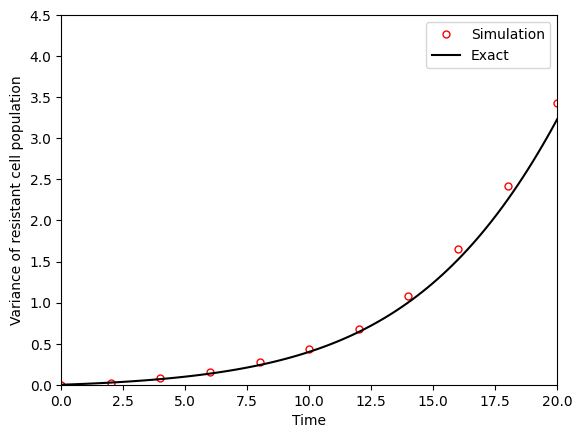

In [41]:
N = 20000 #Number of trials. Need a lot for this (~5000)
T = 20
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1
B1 = 0.1
grid, mean_pop, mean_r, probs, var = get_mean_trajectory_double(N, T, M0, R0, 
                                                            example_rates_double, beta, u, B1, C2)
plt.plot(grid, var, 'o', c = 'red', markevery = 2, markersize = 5, fillstyle = 'none', label = f'Simulation' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_R(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()

plt.xlim(0, 20)
plt.ylim(0, 4.5)

plt.ylabel('Variance of resistant cell population')
plt.xlabel('Time')


plt.savefig('Figs/double_type_variance.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

For large N i can match analytical result, so I don't think the issue is on my side. var at T = 20 should be ~ 4, but I get ~3.2. Could be parameter issue, need to check these. Maybe find a more general way to do it

In [55]:
#----------------------------

Look at single type Var, as Ruby \& Janet noticed issues

In [58]:
#Analytical solution for single-type as per paper

**Var[Z(t)]**
The paper has definitley made a mistake. Ruby has derived the correct analytical solution, which perfectly matches the numerical solution, (which I have faith in).
Need to track the process. I originally tried the papers solution. Staggering difference. \
Give the net positive rate, the variance should be large. The issue is that they should have excluded the exponential in w(t) or included it, but removed from the final; equation. \
Can show that we also checked the approximate variance and showed that it should be large. 

Fig 3: Pre-existanxce \
We are looking at the expected number of resistant cells and the probability of resistance, given a pre-exisiting population R. \
\
s should be easy to include where the pre existing population S(0) = M(1-s) and R(0) = Ms. \
We have a 14 day on/off dosing schedule.

In [42]:
#define rates for this example. See function simulate_pulsed_therapy for definition and explanation
rates = {
        'on':  {'lx': 0.05, 'ly': 0.11, 'mux': 0.1, 'muy': 0.1},
        'off': {'lx': 0.13, 'ly': 0.15, 'mux': 0.1, 'muy': 0.1}
    }

#t , s, r = simulate_pulsed_therapy(rates, T_max, M0, beta, u, cycle_length, dosing_length, s)

Fig 3.a: Expected number of resistant cells for some pre-existing resistant poplation, for a dosing schedule
Analytical missing, circles look good though

In [ ]:
#Define analytical solutions
#R(T) = R_sens(T) + R_res(T)
#R_sens(T) eq(7), already used
#update params. Use M(1-s)

def get__rate(t, cell_type, rate_type):
    # 14 days on (0-14), 14 days off (14-28)
    phase = 'on' if (t % 28) < 14 else 'off'
    return rates[phase][rate_type]


def b_pulsed(t, M, s, u):
    lx, ux, _, _ = get_rates(t)
    
    # We need the integral of (lx - ux) from 0 to t
    # For pulsed schedules, quad is still the easiest way to handle the step function
    def net_growth_s(tau):
        l, u_rate, _, _ = get_rates(tau)
        return l - u_rate
    
    integral_val, _ = integrate.quad(net_growth_s, 0, t)
    return (M*(1-s)) * np.exp(integral_val) * lx * u

def R_t_pulsed(t, M, s, u):
    def integrand(tau):
        b_val = b_pulsed(tau, M, s, u)
        
        def net_growth_r(eta):
            _, _, ly, uy = get_rates(eta)
            return ly - uy
            
        growth_val, _ = integrate.quad(net_growth_r, tau, t)
        return b_val * np.exp(growth_val)
    
    res, _ = integrate.quad(integrand, 0, t)
    return res




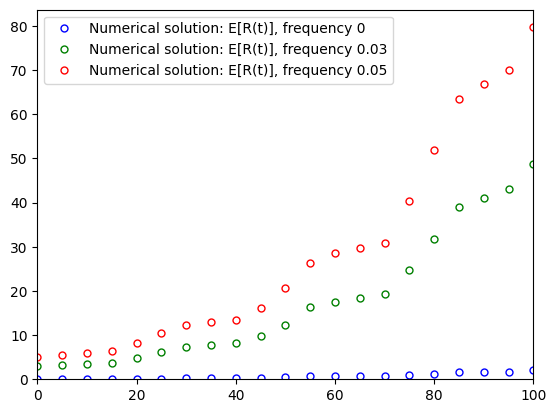

In [36]:
T_max = 100
M0 = 100 # Not specified, this is an assumption
beta = 0.5
u = 1e-3
cycle = 28
dosing = 14
N = 500

freq = [0, 0.03, 0.05]
colours = ['blue', 'green', 'red']
g = zip(freq, colours)

for s, cols in g:
    grid, pop_s, pop_r, prob_r, var_r = mean_pulsed_therapy(N, T_max, M0, rates, beta, u, cycle, dosing, s)
    plt.plot(grid, pop_r, 'o', c = cols, label = f'Numerical solution: E[R(t)], frequency {s}',
             markevery = 5, markersize = 5, fillstyle = 'none')

plt.xlim(0, T_max)
plt.ylim(0, None)
plt.legend()
plt.show()

Fig 3.b: Probability of Resistance given some pre-existing resistant cell population for some dosing schedule

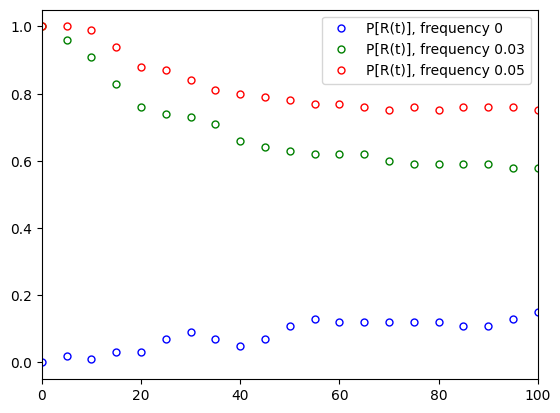

In [33]:
T_max = 100
M0 = 100 # Not specified, this is an assumption
beta = 0.5
u = 1e-3
cycle = 28
dosing = 14
s = 0.03
N = 100

frequencies = [0, 0.03, 0.05]
colours = ['blue', 'green', 'red']
g = zip(frequencies, colours)

for s, cul in g:
    grid, pop_s, pop_r, prob_r, var_r = mean_pulsed_therapy(N, T_max, M0, rates, beta, u, cycle, dosing, s)
    plt.plot(grid, prob_r,'o', c = cul, label = f'P[R(t)], frequency {s}',
              markevery = 5, fillstyle = 'none', markersize = 5 )

#xlim and ylim let us cut the axis rather than have padding on either side. Looks better
plt.xlim(0, T_max)
plt.xlim(0, None) 
plt.legend()
plt.show()

Section 4.4: Effect of drug accumulation on the evolution of resistance 

Concentration over time after one dose is given below as C, where D is the daily drug of the dose in some arbitrary unit. k is the rat eof drug elimination

Fig 4.a: Drug concentration, lambda_x, lambda_y as a function of time


In [2]:
D = 0.6 #maintenance dose
tau = 1 #spacing interval
k = 0.2 #decay rate
load = D / (1 - np.exp(-k * tau)) #loading dose
M0 = 1e6 #initial sensitive cell population
u = 1e-8 #mutation rate

In [3]:
#Plot concentration
def concentration(D, k, t):
    return D * np.exp(-k*t)

In [6]:
T = 30
tau = 1
N = T/tau
#time = np.linspace(0, T, N)
def get_concentration(t, D, kappa, tau, loading_dose = False):
    n = int(t / tau) + 1  # Current dose number
    time_since_last = t % tau
    if loading_dose == False:
        D_load = D
    else:
        D_load = D / (1-np.exp(-kappa*tau))
    if n == 1:
        # We are in the first interval; only the loading dose exists
        c_peak = D_load
    else:
        # n-th peak = (Residual of D_load) + (Accumulation of n-1 maint doses)
        # Note: the loading dose has decayed for (n-1) intervals
        term1 = D_load * np.exp(-(n-1) * kappa * tau)
        
        # The maintenance doses have accumulated for (n-1) steps
        term2 = D * (1 - np.exp(-(n-1) * kappa * tau)) / (1 - np.exp(-kappa * tau))
        
        c_peak = term1 + term2
        
    return c_peak * np.exp(-kappa * time_since_last)




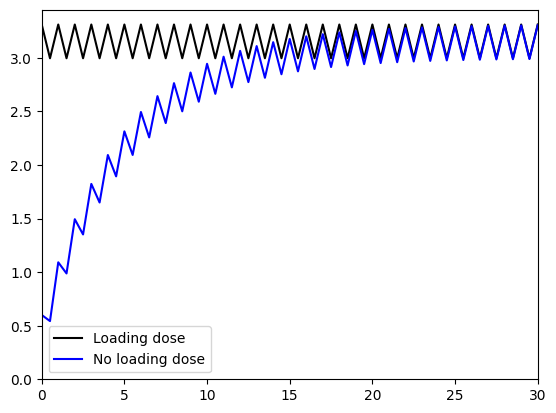

In [5]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

for i, g in enumerate(time):
    store_LD[i] = get_concentration(g, D, k, tau, True)
    store_NLD[i] = get_concentration(g, D, k, tau, False)
plt.plot(time, store_LD, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD, c = 'blue', label = 'No loading dose')
plt.legend()
plt.xlim(0, T)
plt.ylim(0, None)
plt.show()




In [26]:


def lamb_x(lx, t, D, k, tau, c_max, loading_dose = False):
    #get_concentration(0, D, k, tau, True) + get_concentration(0, D, k, tau, False)
    c = get_concentration(t, D, k, tau, loading_dose)
    rate = lx * (c_max - c)
    return rate, c


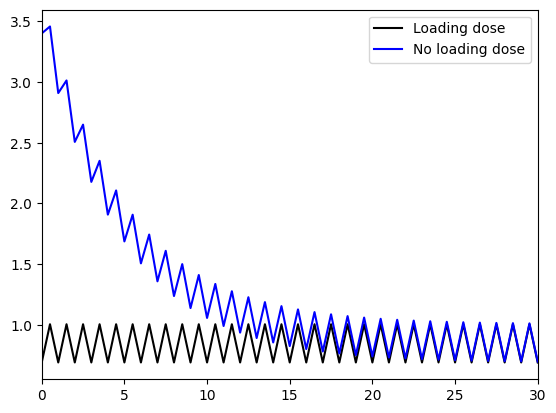

In [27]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

M0 = 1e6
u = 1e-8

lx = 0.1

for i, g in enumerate(time):
    rate, _ = lamb_x(lx, g, D, k, tau, 4, True)
    store_LD[i] = rate *M0 *u
    rate_, _ = lamb_x(lx,g, D, k, tau, 4, False)
    store_NLD[i] = rate_ *M0 *u
plt.plot(time, store_LD *1e3, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD *1e3, c = 'blue', label = 'No loading dose')
plt.legend()
plt.xlim(0, T)
plt.ylim(None, None)
plt.show()

This section seems very poorly explained and took a lot of trial and error to figure out. \
Above is the birth rate of resistant cells from a sensitive cell population. \
The rat eis the per-capita rate times the mutation rate.\
The percapita rate is the rate times the population \
rate is birth rate times the accumulated drug. This is done as c_max - current accumulated concentration. This means that, with a loading dose for example, the birth rate is lower. The drug should lower the birth of resistant cells. As the drug accumulates the rate lowers. The steady state remaimns the same, with a sawtooth pattern.

In [55]:
def lamb_y(t, D, k, tau, loading_dose = False):
    ly = 0.0775 #A bit lower given lower fitness cost
    c_max = get_concentration(0, D, k, tau, True) + get_concentration(0, D, k, tau, False)
    #lx = A * np.sin(theta * t) + B1
    rate = ly * (c_max - (0.1 * get_concentration(t, D, k, tau, loading_dose))) #scale given partial resistance to the drug 
    return rate

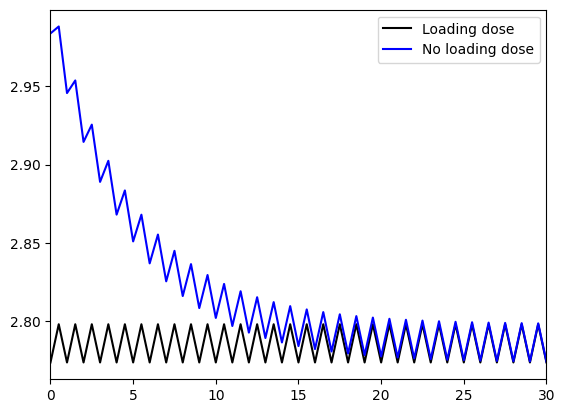

In [56]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

M0 = 1e6
u = 1e-8

for i, g in enumerate(time):
    store_LD[i] = lamb_y(g, D, k, tau, True) * M0 * u
    store_NLD[i] = lamb_y(g, D, k, tau, False) * M0 * u
plt.plot(time, store_LD *1e3, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD * 1e3, c = 'blue', label = 'No loading dose')
plt.legend()
plt.xlim(0, T)
plt.ylim(None, None)
plt.show()

Fig 4b: Show how rates change with drug concentration

If we use our system, there is some beginning dose. So we can never really have 0 units with out system, even at t=0, there'd still be a doseage. So I've set up a new system, that is simplistic, but shows the evolution of the rates

Maybe I should just add a counter the the sawtooth approach above

In [48]:
#def a function of birth & death rates
def rates_conc(lx, ly, mux, muy, c_max, units, a):
    '''
    Input is constant rates.
    For this model assume constant birth and death rates.
    Death rates are unaffected by drug concentration
    birth rate is affected by drug concentration

    lx, ly, mux, muy are constant birth and death rate sof sensitive and resistant cells
    c_max is max possible drug accumulation/concentration which will completely offset the baseline rate
    units is input units of drug concentration(arbitrary)
    a is scaling factor
    '''
    
    l_x = lx * ((c_max - units) / c_max)
    l_y = ly * ((c_max - (a * units)) / c_max)
    mu_x = mux
    mu_y = muy


    return l_x, l_y, mu_x, mu_y


In [49]:
conc = np.linspace(0, 20, 21)
lx, ly, mx, my =  [np.zeros(len(conc)) for i in range(4)]

for i, x in enumerate(conc):
    lx[i], ly[i], mx[i], my[i] = rates_conc(0.4, 0.3, 0.2, 0.13, 4, x, 0.13)

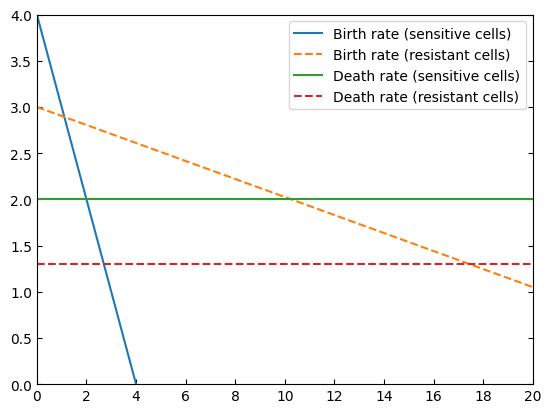

In [50]:
M0 = 1e6
u = 1e-8
plt.plot(conc, lx * M0 * u * 1e3, label = 'Birth rate (sensitive cells)')
plt.plot(conc, ly * M0 * u * 1e3, label = 'Birth rate (resistant cells)', linestyle = '--')
plt.plot(conc, mx * M0 * u * 1e3, label = 'Death rate (sensitive cells)')
plt.plot(conc, my * M0 * u * 1e3, label = 'Death rate (resistant cells)', linestyle = '--')

plt.xlim(0, 20)
plt.ylim(0, 4)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.legend()
plt.gca().tick_params(right=True, direction='in')
plt.show()

Fig 4.c Probability of resistance with and without a loading dose. \
Should use analytical P_R(T, B1) \
I'm struggling big time with this

Fig 5.a

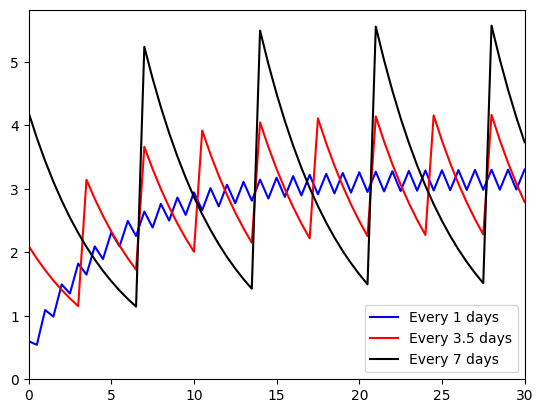

In [23]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = [1, 3.5, 7]
colours = ['blue', 'red', 'black']
#To maintain the AUC we need D_new = D_1 * tau_new/tau_1
#tau_1 = 1 so just 0.6 * tau_new
#see notes for derivation. Solve AUC = integral(C(t)) form o to inf
D = 0.6
dict = zip(tau, colours)
for t, col in dict:
    for i, g in enumerate(time):
        store_NLD[i] = get_concentration(g, (D*t), k, t, False)
    plt.plot(time, store_NLD, c = col, label = f'Every {t} days')
plt.legend()
plt.xlim(0, T)
plt.ylim(0, None)
plt.show()

Fig 5.b Probability of resistance for varying frequencies as above. Dno how to do this

Fig 6.a

This plot is to simply show the relationship between the administed frequency and the tolerated dose. We use an exponential decay. $$g(x) = a \cdot \exp ^{-b}$$

In [35]:
def g_x(a, x):

    g_x = a * np.exp(-0.3 * x)
    return g_x

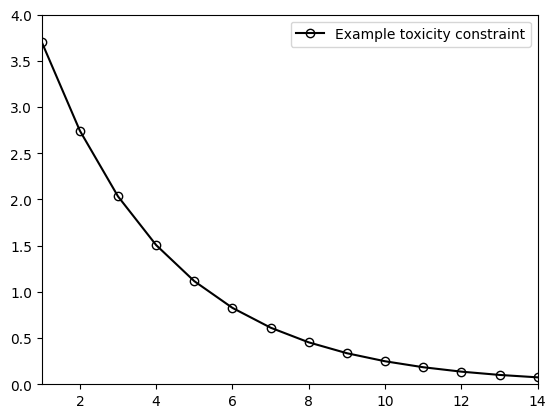

In [42]:
frequency = np.linspace(1, 14, 14)
results = np.zeros(len(frequency))

for i, x in enumerate(frequency):
    results[i] = g_x(5, x)

plt.plot(frequency, results, label = 'Example toxicity constraint', marker = 'o', fillstyle = 'none', c = 'black')
plt.legend()
plt.xlim(1, 14)
plt.ylim(0, 4)
plt.show()



Fig 6.b: Rate Vs Drug concentration. 

In [79]:
conc = np.linspace(0, 10, 11)
lx, ly, mx, my =  [np.zeros(len(conc)) for i in range(4)]

for i, x in enumerate(conc):
    lx[i], ly[i], mx[i], my[i] = rates_conc(0.4, 0.3, 0.2, 0.2, 2.5, x, 0.08)

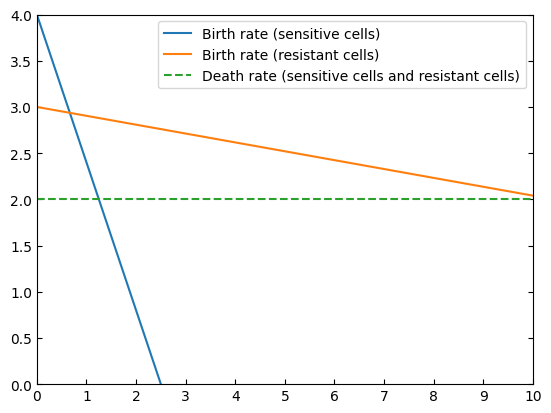

In [81]:
M0 = 1e6
u = 1e-8
plt.plot(conc, lx * M0 * u * 1e3, label = 'Birth rate (sensitive cells)')
plt.plot(conc, ly * M0 * u * 1e3, label = 'Birth rate (resistant cells)')
plt.plot(conc, mx * M0 * u * 1e3, label = 'Death rate (sensitive cells and resistant cells)', linestyle = '--')
#plt.plot(conc, my * M0 * u * 1e3, label = 'Death rate (resistant cells)', linestyle = '--')

plt.xlim(0, 10)
plt.ylim(0, 4)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.legend()
plt.gca().tick_params(right=True, direction='in')
plt.show()

Fig 6c: Probability of resistant cells at T = 120 for various dosing schedules \
I realise I have been approaching this completely wrong. I should be using analytical solution sfor section 4 where possible

In [90]:
def get_rates_for_sim(t, D, tau):
    '''
    Need a function, which is time dependent, to return the rates as we defined earlier
    '''
    k = 0.2 
    c = get_concentration(t, D, k, tau, loading_dose=True)
    

    
    #Use fig 6 rates, where c is time dependent
    l_x = 0.4 * ((2.5 - c) / 2.5)
    
    l_y = 0.3 * ((2.5 - (0.08 * c)) / 2.5)
    
    #May not need to enforce this
    # l_x = max(0, float(l_x))
    # l_y = max(0, float(l_y))
    
    mu_x = 0.2
    mu_y = 0.2
    
    return l_x, l_y, mu_x, mu_y

In [91]:
freqs = np.linspace(1, 11, 11)
p_res = []

for x in freqs:
    #Define tau and D. This is on a per week basis
    tau = 7.0 / x
    D = g_x(5, x)
    
    trials = 1
    res_count = 0
    
    for _ in range(trials):
        # Only need final population count at T = 120
        _, M_path, R_path = simulate_population_double(
            func=get_rates_for_sim, 
            T_max=120, 
            M0=1e3, 
            R0=0, 
            beta=1.0, 
            u=1e-5, 
            B1=D,     
            C2=tau    
        )
        
        # Check if resistant cells exist at the end
        if R_path[-1] > 0:
            res_count += 1
            
    p_res.append(res_count / trials)